In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
housing_data = fetch_california_housing()
df_housing = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
df_housing["Price"] = housing_data.target

df_housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Učitavamo California Housing dataset direktno iz sklearn biblioteke.
Dodajemo ciljnu varijablu Price koja predstavlja cijenu kuće.

In [2]:
df_housing.info()
df_housing.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Provjeravamo strukturu podataka i osnovne statistike.
Vidimo da dataset nema nedostajućih vrijednosti i spreman je za obradu.

In [3]:
X = df_housing.drop("Price", axis=1)
y = df_housing["Price"]

X su ulazne varijable (featurei), a y je ciljna varijabla koju želimo predvidjeti.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Skaliranje je važno jer neuronske mreže bolje rade kada su podaci na istoj skali.
Bez skaliranja model može sporije učiti i davati lošije rezultate.

In [6]:
from sklearn.neural_network import MLPRegressor

model_simple = MLPRegressor(
    hidden_layer_sizes=(20,),
    activation='relu',
    max_iter=300,
    random_state=10
)

model_simple.fit(X_train_scaled, y_train)
pred_simple = model_simple.predict(X_test_scaled)

Najjednostavniji model – jedan skriveni sloj s 20 neurona.
Ovo je baseline model za usporedbu.

In [7]:
model_medium = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=300,
    random_state=10
)

model_medium.fit(X_train_scaled, y_train)
pred_medium = model_medium.predict(X_test_scaled)

Model sa dva sloja – više kapaciteta za učenje kompleksnijih odnosa.

In [8]:
model_complex = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=300,
    random_state=10
)

model_complex.fit(X_train_scaled, y_train)
pred_complex = model_complex.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Najkompleksniji model s tri sloja.
Može bolje učiti, ali postoji rizik overfittinga.

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

res_simple = evaluate_model(y_test, pred_simple)
res_medium = evaluate_model(y_test, pred_medium)
res_complex = evaluate_model(y_test, pred_complex)

Računamo tri metrike za svaki model:
RMSE- greška
MAE - prosječna pogreška
R² - koliko model objašnjava podatke

In [11]:
results = pd.DataFrame({
    "Model": ["Simple", "Medium", "Complex"],
    "RMSE": [res_simple[0], res_medium[0], res_complex[0]],
    "MAE": [res_simple[1], res_medium[1], res_complex[1]],
    "R2": [res_simple[2], res_medium[2], res_complex[2]]
})

results.round(3)

,Model,RMSE,MAE,R2
0,Simple,0.571,0.389,0.761
1,Medium,0.528,0.355,0.796
2,Complex,0.540,0.346,0.786


Rezultate prikazujemo u tablici radi lakše usporedbe.

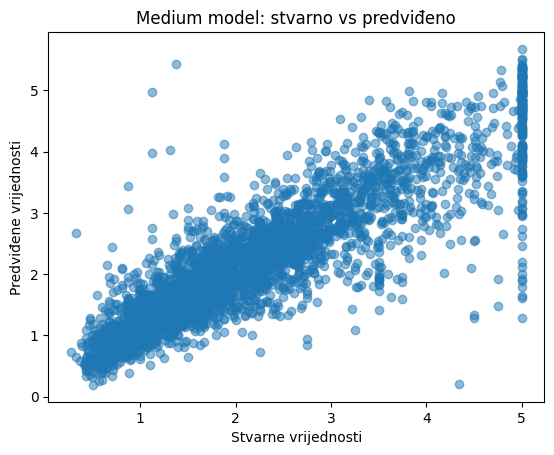

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred_medium, alpha=0.5)
plt.xlabel("Stvarne vrijednosti")
plt.ylabel("Predviđene vrijednosti")
plt.title("Medium model: stvarno vs predviđeno")
plt.show()

Vizualno prikazujemo koliko su predviđanja blizu stvarnih vrijednosti.

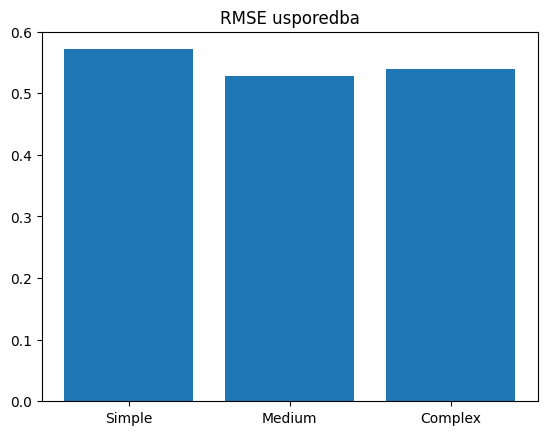

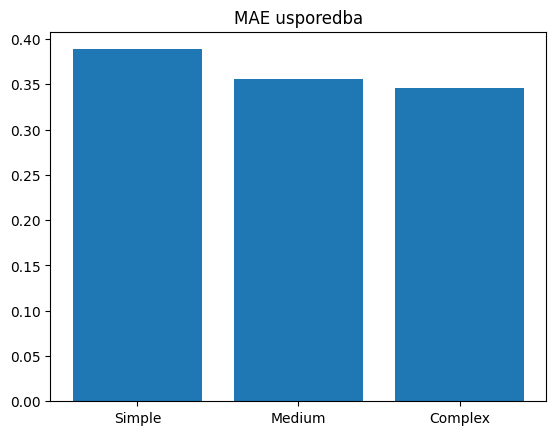

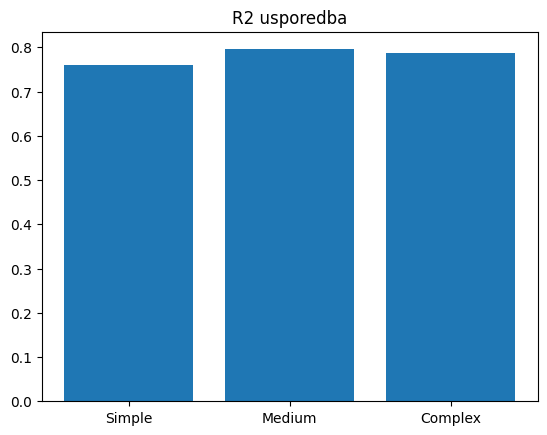

In [13]:
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE usporedba")
plt.show()
plt.bar(results["Model"], results["MAE"])
plt.title("MAE usporedba")
plt.show()
plt.bar(results["Model"], results["R2"])
plt.title("R2 usporedba")
plt.show()

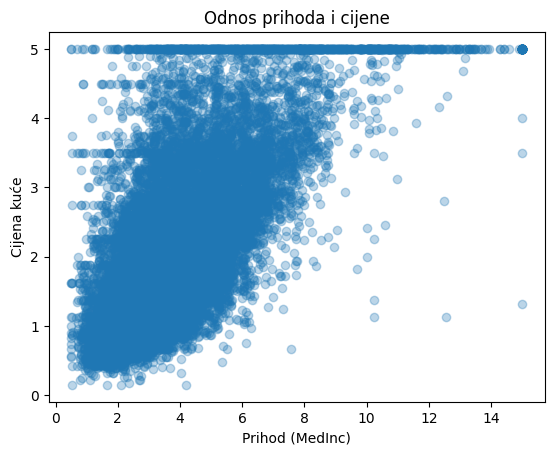

In [14]:
plt.scatter(df_housing["MedInc"], df_housing["Price"], alpha=0.3)
plt.xlabel("Prihod (MedInc)")
plt.ylabel("Cijena kuće")
plt.title("Odnos prihoda i cijene")
plt.show()

Prikazujemo odnos između jedne značajke i ciljne varijable.

U ovom radu uspoređene su tri različite arhitekture MLPRegressor modela.
Rezultati pokazuju da srednje složen model (Medium) daje najbolje performanse, s najnižim RMSE i MAE te najvećim R².
Jednostavan model nema dovoljno kapaciteta za učenje složenih odnosa, dok najkompleksniji model ne daje značajno bolje rezultate i može pokazivati znakove overfittinga.
Zaključno, povećanje složenosti modela ne mora uvijek dovesti do boljih rezultata, već je važno pronaći optimalnu arhitekturu.